In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../raw_datasets/Customer_Attributes_and_Purchase_Propensity.csv")
df.head()

,Age,Income,City,Marital_Status,Score,Purchased
0,56,24000,Houston,Divorced,0.479897,0
1,46,90588,Chicago,Single,0.685968,1
2,32,113610,Houston,Divorced,0.017380,0
3,60,117856,New York,Married,0.323131,0
4,25,58304,Houston,Single,0.973098,0


In [3]:
df.nunique()

Age                47
Income            499
City                5
Marital_Status      3
Score             500
Purchased           2
dtype: int64

In [4]:
# label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             500 non-null    int64  
 1   Income          500 non-null    int64  
 2   City            500 non-null    int32  
 3   Marital_Status  500 non-null    int32  
 4   Score           500 non-null    float64
 5   Purchased       500 non-null    int64  
dtypes: float64(1), int32(2), int64(3)
memory usage: 19.7 KB


<Axes: >

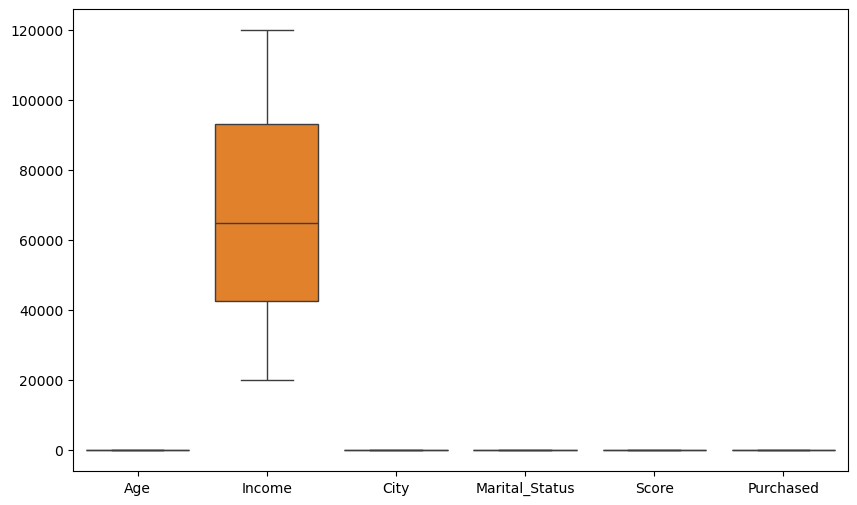

In [19]:
# check outliers in single plot
plt.figure(figsize=(10,6))
sns.boxplot(data=df)

In [20]:
# print the number of outliers in each column
for col in df.columns:
    outliers = df[(df[col] < df[col].quantile(0.25) - 1.5 * (df[col].quantile(0.75) - df[col].quantile(0.25))) | (df[col] > df[col].quantile(0.75) + 1.5 * (df[col].quantile(0.75) - df[col].quantile(0.25)))]
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Income: 0 outliers
City: 0 outliers
Marital_Status: 0 outliers
Score: 0 outliers
Purchased: 0 outliers


<Axes: >

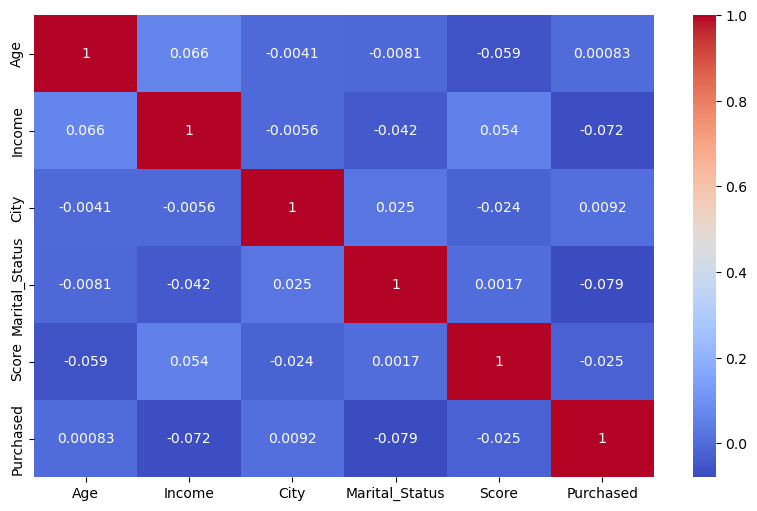

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [8]:
# standard scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=df.drop('Purchased', axis=1)
y=df['Purchased']
X_scaled=scaler.fit_transform(X)


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [10]:
# logistic regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
y_train_pred=model.predict(X_train)

In [11]:
# knn classifier
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn=knn.predict(X_test)
y_train_pred_knn=knn.predict(X_train)

In [12]:
# decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt=dt.predict(X_test)
y_train_pred_dt=dt.predict(X_train)

In [13]:
# random forest classifier
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf=rf.predict(X_test)
y_train_pred_rf=rf.predict(X_train)

In [16]:
#svm
from sklearn.svm import SVC
svm=SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm=svm.predict(X_test)
y_train_pred_svm=svm.predict(X_train)

In [17]:
# navie bayes
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb=nb.predict(X_test)
y_train_pred_nb=nb.predict(X_train)

In [18]:
from sklearn.metrics import accuracy_score
print("Logistic Regression Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_pred))
print("==================================================================")
print("KNN Train Accuracy:", accuracy_score(y_train, y_train_pred_knn))
print("KNN Test Accuracy:", accuracy_score(y_test, y_pred_knn))
print("==================================================================")
print("Decision Tree Train Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("Decision Tree Test Accuracy:", accuracy_score(y_test, y_pred_dt))
print("==================================================================")
print("Random Forest Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("==================================================================")
print("SVM Train Accuracy:", accuracy_score(y_train, y_train_pred_svm))
print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("==================================================================")
print("Naive Bayes Train Accuracy:", accuracy_score(y_train, y_train_pred_nb))
print("Naive Bayes Test Accuracy:", accuracy_score(y_test, y_pred_nb))

Logistic Regression Train Accuracy: 0.6125
Logistic Regression Test Accuracy: 0.42
KNN Train Accuracy: 0.7175
KNN Test Accuracy: 0.44
Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.52
Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.45
SVM Train Accuracy: 0.68
SVM Test Accuracy: 0.45
Naive Bayes Train Accuracy: 0.6075
Naive Bayes Test Accuracy: 0.44


In [21]:
df=pd.read_csv("../raw_datasets/Customer_Attributes_and_Purchase_Propensity.csv")

In [22]:
df.to_csv("../processed_datasets/Customer_Attributes_and_Purchase_Propensity_processed.csv", index=False)